# 04 — TotalSegmentator2D (TSXR)

Třetí porovnávaný přístup. Na rozdíl od U-Netu a UNETR se **netrénuje** — jde
o hotový, obecný, předtrénovaný model, který se jen pustí na naše data.

Reprezentuje otázku: *„Vyplatí se trénovat vlastní model, když existuje hotové
obecné řešení?"*

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from _common import *
import cv2, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
print("repo:", REPO_ROOT)

repo: C:\GitHub\USU-zapocet


## 1. Co model umí a co potřebujeme my

TSXR segmentuje **26 anatomických struktur** (kost křížová, L1–L5, T1–T12,
C1–C7). Nás z toho zajímá jen šest krčních obratlů.

Skript `scripts/ts2d_inference.py` proto výstup filtruje a přemapovává na naši
škálu 0–6. Mapování se dělá **podle jmen tříd**, ne podle natvrdo zapsaných
čísel — jiná revize modelu by mohla mít jiné pořadí a maska by se tiše
přemapovala špatně.

In [2]:
model_dir = Path.home() / ".ts2d" / "models" / "tsxr-v2-ep1000b2_vertebrae" / "r001"
ds = list(model_dir.rglob("dataset.json"))
if ds:
    meta = json.loads(ds[0].read_text(encoding="utf-8"))
    print("kanály na vstupu:", meta["channel_names"])
    print(f"tříd celkem: {len(meta['labels'])}")
    print("\nkrční obratle a jejich ID v modelu:")
    for name, v in meta["labels"].items():
        if name.startswith("vertebrae-c"):
            print(f"  {name:16s} -> {v}")
else:
    print("Model není nakešovaný — viz devnotes/PROSTREDI_A_PASTI.md §4.3")

kanály na vstupu: {'0': 'XR'}
tříd celkem: 27

krční obratle a jejich ID v modelu:
  vertebrae-c7     -> 20
  vertebrae-c6     -> 21
  vertebrae-c5     -> 22
  vertebrae-c4     -> 23
  vertebrae-c3     -> 24
  vertebrae-c2     -> 25
  vertebrae-c1     -> 26


### Poznámky k rozchození (stálo to nejvíc času)

Postupně se narazilo na čtyři nezávislé překážky — všechny jsou popsané
v [`devnotes/PROSTREDI_A_PASTI.md`](../devnotes/PROSTREDI_A_PASTI.md):

1. **Stahování modelů v nástroji je rozbité** — používá knihovnu `gdown`
   (určenou pro Google Drive) na Zenodo URL; stáhne 763 bajtů místo 250 MB.
   Model se musel stáhnout ručně přes `curl`.
2. **`torchvision` nesměl zůstat ze starého buildu** — jinak inference padá
   hluboko uvnitř nnU-Netu na `operator torchvision::nms does not exist`.
   Torch, torchvision i torchaudio musí být ze stejného CUDA buildu.
3. **CLI nepřijímá PNG** (jen `nrrd/nii/mha/mhd`) → obchází se Python API.
4. **Vstup musí být jednokanálový** a se **správným fyzickým rozlišením** —
   nnU-Net podle něj vstup převzorkovává.

## 2. Inference

Nejdřív pár snímků, ať je vidět, co model vrací.

In [3]:
run_script("scripts/ts2d_inference.py", "--split", "test", "--limit", "3", "--preview")

$ py -3 -u scripts/ts2d_inference.py --split test --limit 3 --preview



[ts2d] startuji model 'tsxr_vertebrae' (nnU-Net startuje subproces, chvili to trva)...


[ts2d] model pripraven za 23.9 s


[mapovani] model vraci 26 trid, z toho relevantnich 6:


    hodnota modelu  25 -> nase trida 1


...

[ts2d] prvni maska hotova, nalezene tridy: [0]


[ts2d] hotovo: 3/3 masek za 3.4 s (1.15 s/snimek), chyb: 0


[ts2d] vystup: C:\GitHub\USU-zapocet\training_outputs\predictions\ts2d



[navratovy kod: 0]


0

vyrobených masek: 3
třídy v ground truth: [0 1 2 3 4 5 6]
třídy v predikci TS2D: [0]


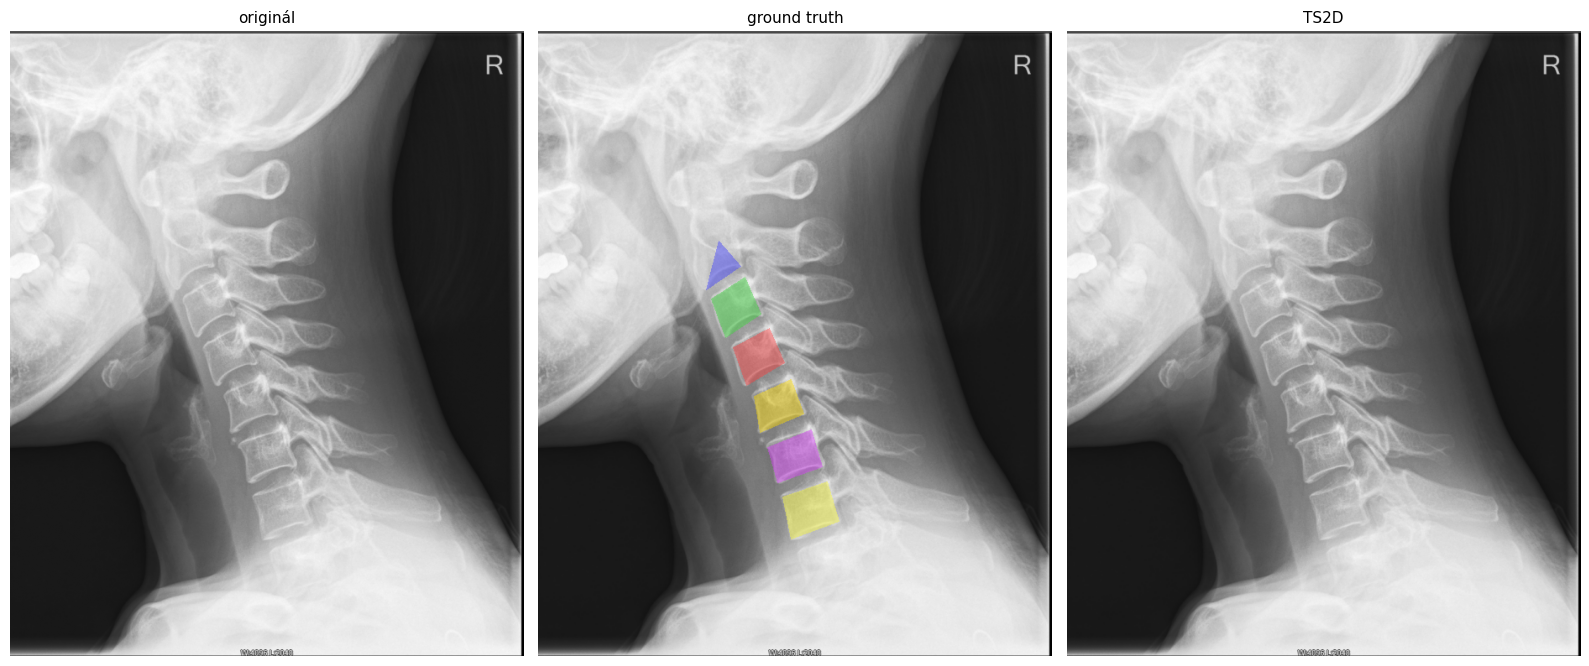

In [4]:
ts2d_dir = OUTPUTS_DIR / "predictions" / "ts2d"
preds = sorted(ts2d_dir.glob("*.png"))
print(f"vyrobených masek: {len(preds)}")

if preds:
    stem = preds[0].stem
    img = cv2.imread(str(IMAGES_DIR / f"{stem}.png"), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(MASKS_DIR / f"{stem}.png"), cv2.IMREAD_GRAYSCALE)
    pr = cv2.imread(str(preds[0]), cv2.IMREAD_GRAYSCALE)
    print("třídy v ground truth:", np.unique(gt))
    print("třídy v predikci TS2D:", np.unique(pr))
    show_row([img, overlay(img, gt), overlay(img, pr)],
             ["originál", "ground truth", "TS2D"], cmap="gray")

## 3. Model krční obratle nenajde

Predikce je prázdná. Model **nenajde ani jeden krční obratel** — místo nich
predikuje kost křížovou a bederní obratle. Na snímku krku.

To je závažné tvrzení. Než ho lze zapsat do zprávy jako *„model na tuto doménu
nepřenáší"*, je nutné vyloučit, že chyba není na naší straně: vykázat cizí model
jako selhávající kvůli vlastní chybě v předzpracování by byl falešný závěr.

Skript `scripts/ts2d_domain_check.py` proto systematicky prochází hypotézy.

In [5]:
# Trvá pár minut — každá kombinace je jedna inference.
run_script("scripts/ts2d_domain_check.py", "--n-images", "1")

$ py -3 -u scripts/ts2d_domain_check.py --n-images 1



OVERENI DOMENOVE PRENOSITELNOSTI TSXR NA KRCNI RENTGENY


Model ocekava (plans.json): rozliseni 1.5 mm/px, median trenink. snimku 226x239 px


Trenovaci intenzity (foreground): mean=17.6 std=16.7 p99.5=84.5


------------------------------------------------------------------------------


...

ZAVER: pokud ani jedna kombinace nenasla krcni obratle, ale model souvisle


predikuje bederni/krizovou oblast, jde o dolozeny domenovy posun, ne o chybu


v nasem predzpracovani. Viz devnotes/STAV_PROJEKTU.md.



[navratovy kod: 0]


0

### Vyloučené hypotézy

| Hypotéza | Jak se testovala | Výsledek |
|---|---|---|
| Špatné volání API | `predict()` vrací strukturovaný výstup | ✗ vyloučeno |
| Špatné mapování kanálů | mapování podle jmen z metadat modelu | ✗ vyloučeno |
| Špatné měřítko | spacing 1,0 / 0,7 / 0,5 / 0,35 / 0,25 / 0,15 mm/px | ✗ vyloučeno |
| Obrácená polarita | invertovaný snímek | ✗ vyloučeno |
| Rozbité váhy | predikce jsou prostorově souvislé, ne šum | ✗ vyloučeno |

Model podle svého `plans.json` očekává rozlišení **1,5 mm/px** a trénoval na
snímcích o mediánu **226×239 px**. Při spacingu 0,5 (což po převzorkování dá
248×193 px, tedy nejblíž tréninkovým datům) predikuje nejvíc — ale pořád kost
křížovou a L3.

### Závěr

TSXR trénoval na syntetických rentgenech (DiffDRR rekonstrukce) z CT datasetu
TotalSegmentator, kde převažuje trup a břicho. **Úzký výřez krční páteře je mimo
jeho doménu.**

Je to **doložený negativní výsledek** — a přesně to, co předpovídá hypotéza
v [`devnotes/plan.md`](../devnotes/plan.md). Do zprávy patří i s tabulkou
vyloučených hypotéz, jinak by to vypadalo jako nedbalost při použití nástroje.

## 4. Inference na celém testovacím setu

~1 s na snímek, tedy zhruba 17 minut pro 992 snímků.

In [6]:
# ODKOMENTUJ pro plný běh:
# run_script("scripts/ts2d_inference.py", "--split", "test")

print("Nebo z terminálu:  py -3 -u scripts/ts2d_inference.py --split test")

Nebo z terminálu:  py -3 -u scripts/ts2d_inference.py --split test


➡️ Dál: [`05_vyhodnoceni.ipynb`](05_vyhodnoceni.ipynb)